# **Generalization with OOPs: Bollinger Bands/Mean Reverson**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [6]:
class BolingerBands():
  def __init__(self, company,period,interval):
    self.company=company
    self.period=period
    self.interval=interval
    self.get_data()

  def get_data(self):
    data=yf.download(self.company,period=self.period,interval=self.interval)
    self.df=pd.DataFrame(data["Close"])
    return self.df

  def calculate_data(self):
    SMA=30;deviation=2;ptc=0.00007
    for ticker in self.company:
      self.df[f"LR {ticker}"]=np.log(self.df[ticker]/self.df[ticker].shift(1))
      self.df[f"SMA {ticker}"]=self.df[ticker].rolling(SMA).mean()
      self.df[f"Lower {ticker}"]=(self.df[f"SMA {ticker}"]-self.df[ticker].rolling(SMA).std())*deviation
      self.df[f"Upper {ticker}"]=(self.df[f"SMA {ticker}"]+self.df[ticker].rolling(SMA).std())*deviation
      self.df[f"Distance {ticker}"]=self.df[ticker]-self.df[f"SMA {ticker}"]
      self.df[f"Position {ticker}"]=np.where(self.df[ticker]<self.df[f"Lower {ticker}"],1,np.nan)
      self.df[f"Position {ticker}"]=np.where(self.df[ticker]>self.df[f"Upper {ticker}"],-1,self.df[f"Position {ticker}"])
      self.df[f"Position {ticker}"]=np.where(self.df[ticker]*self.df[ticker].shift(periods=1)<0,0,self.df[f"Position {ticker}"])
      self.df[f"Strategy {ticker}"]=self.df[f"Position {ticker}"].shift(1)*self.df[f"LR {ticker}"]
      self.df[f"Cumulative Return {ticker}"]=np.exp(self.df[f"LR {ticker}"].cumsum())
      self.df[f"Cumulative Strategy {ticker}"]=np.exp(self.df[f"Strategy {ticker}"].cumsum())
      self.df[f"Trades {ticker}"]=self.df[f"Position {ticker}"].diff().fillna(0).abs()
      self.df[f"Net_Strategy {ticker}"]=self.df[f"Strategy {ticker}"]-self.df[f"Trades {ticker}"]*ptc
      self.df[f"Cumulative Net_Strategy {ticker}"]=np.exp(self.df[f"Net_Strategy {ticker}"].cumsum())
    return self.df.dropna()

  def plot_data(self):
    for ticker in self.company:
      self.df[[f"{ticker}",f"SMA {ticker}"]].plot(figsize=(15,6),fontsize=12)
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Return {ticker}",f"Cumulative Strategy {ticker}",f"Cumulative Net_Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()

  def ann_result(self):
    ann_return=[];ann_risk=[]
    for ticker in self.company:
      ann_return.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].mean()*(4*252))
      ann_risk.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].std()*np.sqrt(4*252))
    print(f"Annual Returns of companies = {ann_return}")
    print(f"Annual Risks of companies = {ann_risk}")
    # return ann_return,ann_risk

In [7]:
BB=BolingerBands(["BSE.NS","HAL.NS","BHEL.NS","BEL.NS"],"3mo","1h")

/tmp/ipython-input-2649830775.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(self.company,period=self.period,interval=self.interval)
[*********************100%***********************]  4 of 4 completed


In [8]:
BB.calculate_data()

Ticker,BEL.NS,BHEL.NS,BSE.NS,HAL.NS,LR BSE.NS,SMA BSE.NS,Lower BSE.NS,Upper BSE.NS,Distance BSE.NS,Position BSE.NS,...,Lower BEL.NS,Upper BEL.NS,Distance BEL.NS,Position BEL.NS,Strategy BEL.NS,Cumulative Return BEL.NS,Cumulative Strategy BEL.NS,Trades BEL.NS,Net_Strategy BEL.NS,Cumulative Net_Strategy BEL.NS
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-14 05:45:00+00:00,422.850006,283.049988,2816.000000,4733.500000,0.005377,2721.979997,5292.645443,5595.274544,94.020003,1.0,...,836.796686,851.876658,0.681670,1.0,-0.002126,1.011603,0.997876,0.0,-0.002126,0.997876
2025-11-14 06:45:00+00:00,424.000000,281.950012,2801.699951,4730.500000,-0.005091,2726.419995,5300.207717,5605.472264,75.279956,1.0,...,837.844303,852.009042,1.536664,1.0,0.002716,1.014354,1.000590,0.0,0.002716,1.000590
2025-11-14 07:45:00+00:00,423.000000,282.850006,2809.199951,4733.600098,0.002673,2731.103328,5308.286239,5616.127074,78.096623,1.0,...,839.117713,851.888964,0.248331,1.0,-0.002361,1.011962,0.998230,0.0,-0.002361,0.998230
2025-11-14 08:45:00+00:00,428.149994,282.000000,2827.300049,4730.000000,0.006422,2737.479997,5321.493094,5628.426893,89.820052,1.0,...,840.140191,852.473152,4.996658,1.0,0.012101,1.024282,1.010383,0.0,0.012101,1.010383
2025-11-14 09:45:00+00:00,426.600006,282.049988,2825.500000,4728.799805,-0.000637,2743.586662,5334.802539,5639.544108,81.913338,1.0,...,841.181411,852.751930,3.116671,1.0,-0.003627,1.020574,1.006726,0.0,-0.003627,1.006726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-09 05:45:00+00:00,438.899994,272.850006,2974.100098,4112.000000,-0.002887,2882.896655,5688.413527,5843.173094,91.203442,1.0,...,860.998957,879.607716,3.748326,1.0,-0.000228,1.050000,1.035752,0.0,-0.000228,1.035752
2026-02-09 06:45:00+00:00,438.450012,272.399994,2967.699951,4125.200195,-0.002154,2886.876652,5691.601395,5855.905213,80.823299,1.0,...,860.989979,879.416694,3.348344,1.0,-0.001026,1.048923,1.034690,0.0,-0.001026,1.034690
2026-02-09 07:45:00+00:00,438.700012,272.700012,2982.600098,4128.100098,0.005008,2891.189990,5694.179192,5870.580769,91.410107,1.0,...,860.989359,879.410649,3.600010,1.0,0.000570,1.049522,1.035280,0.0,0.000570,1.035280


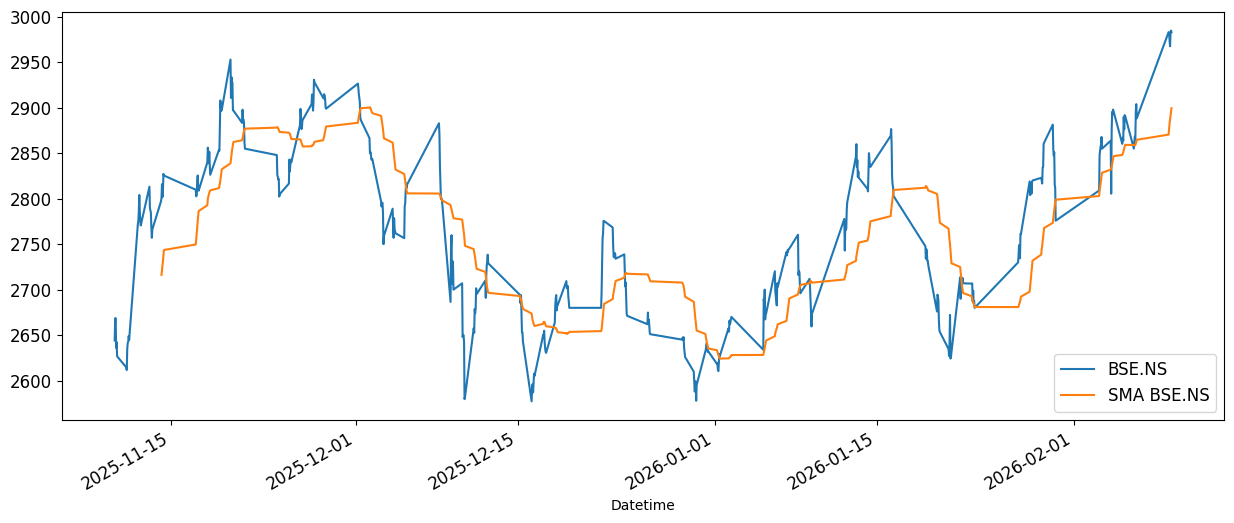

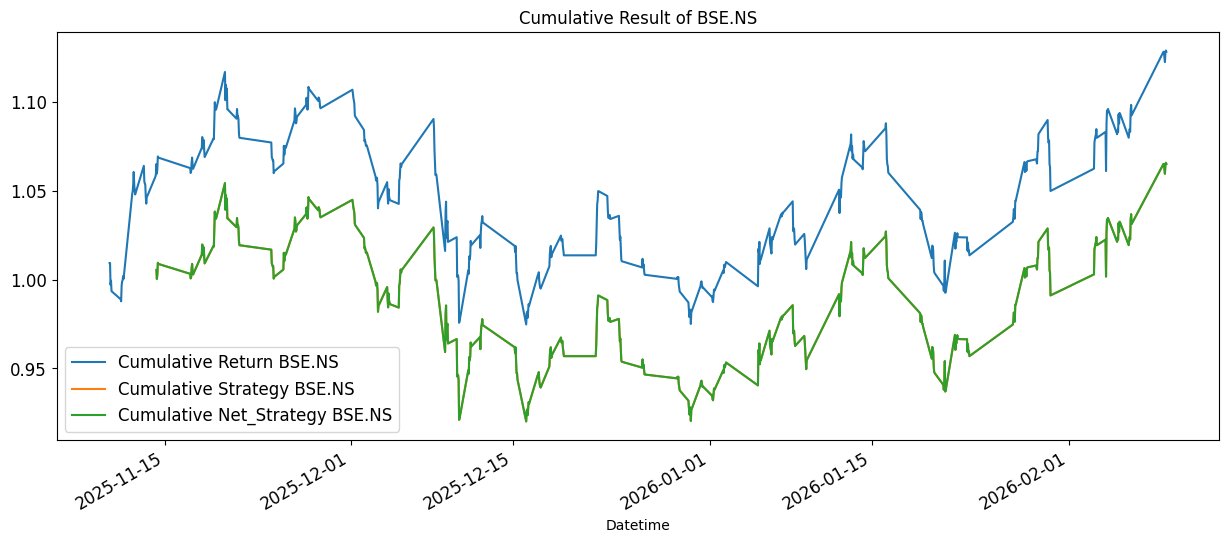

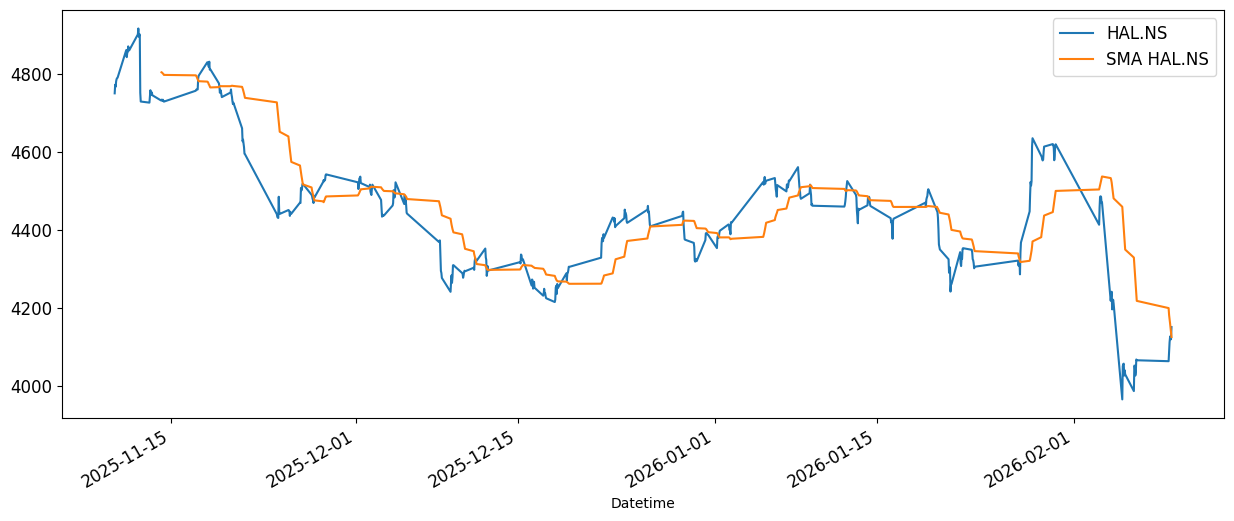

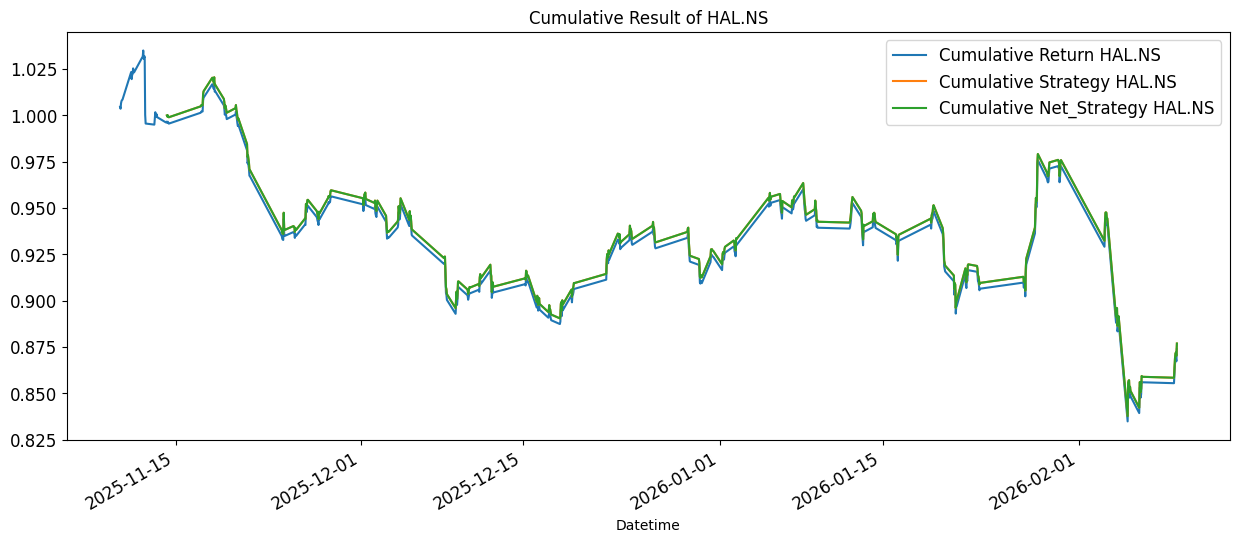

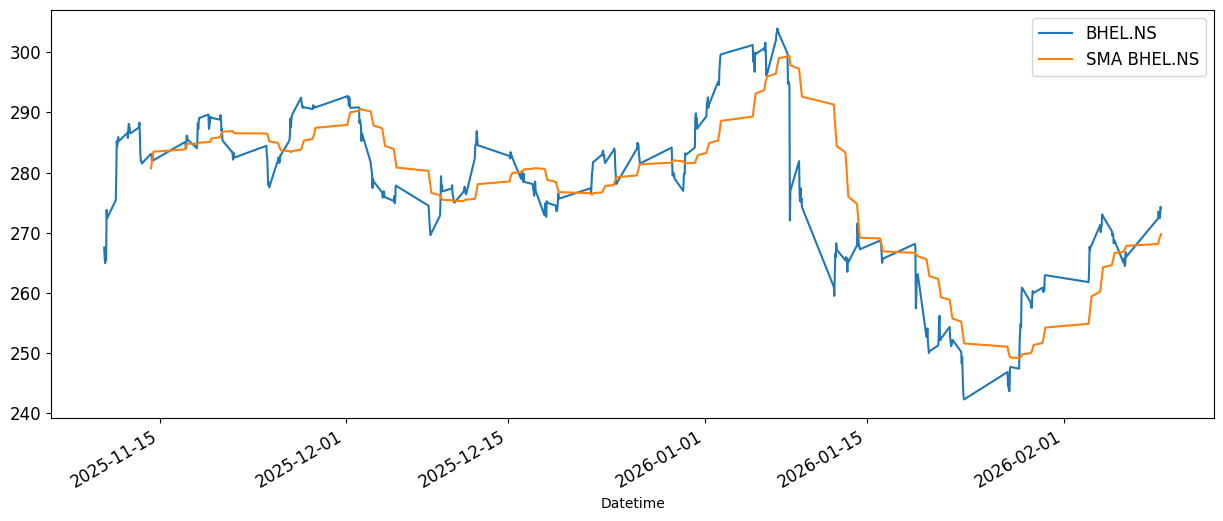

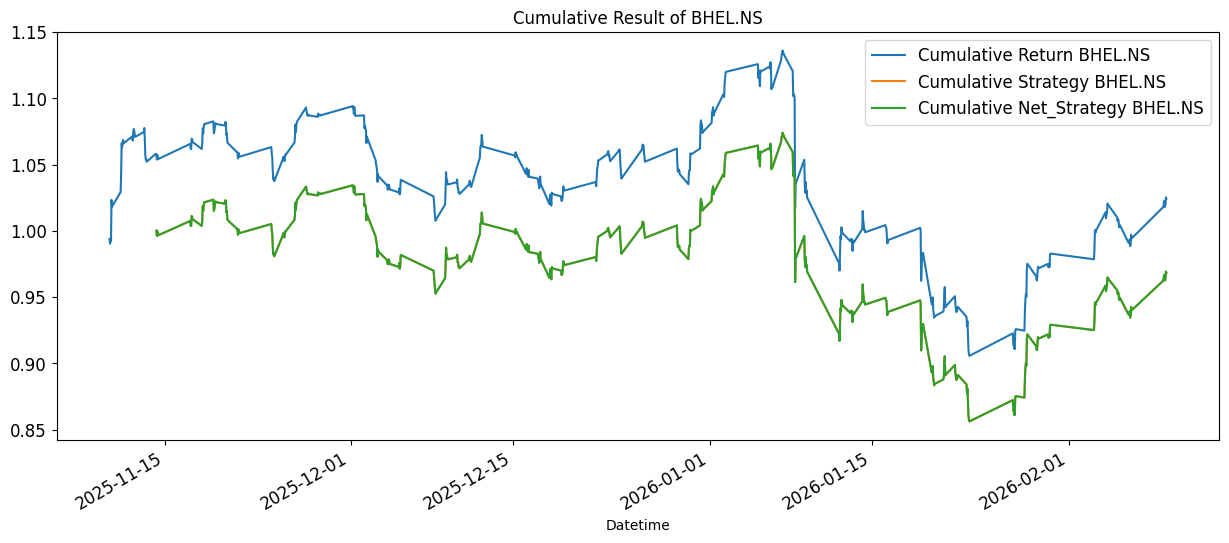

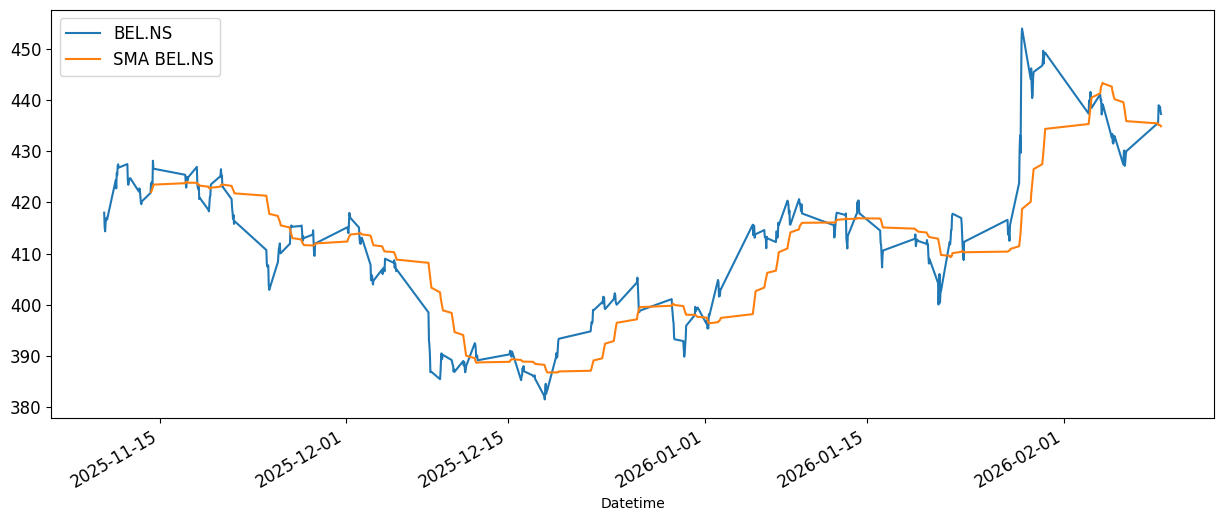

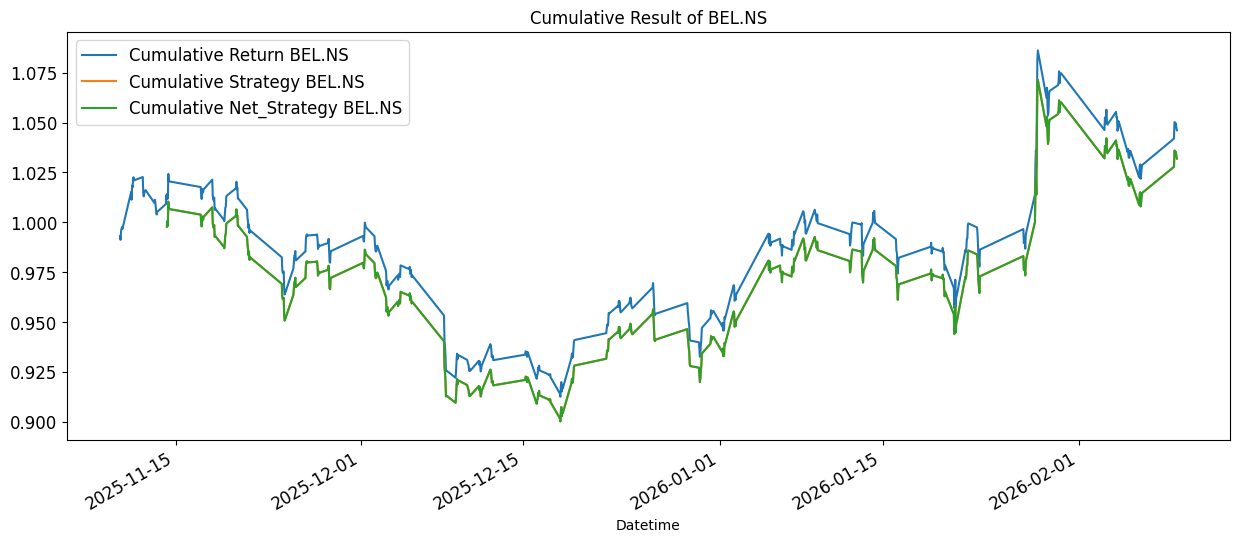

In [9]:
BB.plot_data()

In [10]:
BB.ann_result()

Annual Returns of companies = [Ticker
LR BSE.NS              0.280913
Net_Strategy BSE.NS    0.157244
dtype: float64, Ticker
LR HAL.NS             -0.313796
Net_Strategy HAL.NS   -0.327744
dtype: float64, Ticker
LR BHEL.NS              0.055456
Net_Strategy BHEL.NS   -0.080637
dtype: float64, Ticker
LR BEL.NS              0.105079
Net_Strategy BEL.NS    0.078534
dtype: float64]
Annual Risks of companies = [Ticker
LR BSE.NS              0.254343
Net_Strategy BSE.NS    0.247784
dtype: float64, Ticker
LR HAL.NS              0.223503
Net_Strategy HAL.NS    0.223704
dtype: float64, Ticker
LR BHEL.NS              0.260161
Net_Strategy BHEL.NS    0.259174
dtype: float64, Ticker
LR BEL.NS              0.179034
Net_Strategy BEL.NS    0.180860
dtype: float64]


In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

class BudgetDayStrategy:
    def __init__(self, companies, capital_per_stock=100000):
        self.companies = companies
        self.capital_per_stock = capital_per_stock
        self.today = datetime.now().date()
        self.budget_day = self.today + timedelta(days=1)

    def get_pre_budget_data(self):
        """Get extended data including pre-budget movements"""
        # Get last 10 days data with 5-minute intervals for recent trends
        data = yf.download(self.companies, period="10d", interval="5m")
        self.df = pd.DataFrame(data["Close"])

        # Get daily data for longer-term analysis
        daily_data = yf.download(self.companies, period="3mo", interval="1d")
        self.daily_df = pd.DataFrame(daily_data["Close"])

        return self.df, self.daily_df

    def calculate_pre_budget_signals(self):
        """Calculate multiple technical indicators for pre-budget analysis"""
        signals = {}

        for ticker in self.companies:
            # Bollinger Bands (as per your existing code)
            sma = 20
            bb_std = 2

            df_ticker = self.df[ticker].dropna()

            # Current price position relative to BB
            sma_value = df_ticker.rolling(sma).mean().iloc[-1]
            bb_upper = sma_value + df_ticker.rolling(sma).std().iloc[-1] * bb_std
            bb_lower = sma_value - df_ticker.rolling(sma).std().iloc[-1] * bb_std
            current_price = df_ticker.iloc[-1]

            # RSI (14-period)
            delta = df_ticker.diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
            rs = gain / loss
            rsi = 100 - (100 / (1 + rs))
            current_rsi = rsi.iloc[-1]

            # Volume analysis (if available)
            try:
                vol_data = yf.download(ticker, period="5d", interval="5m", progress=False)
                volume = vol_data['Volume'][ticker] if isinstance(vol_data, pd.DataFrame) else vol_data['Volume']
                avg_volume = volume.rolling(20).mean().iloc[-1]
                current_volume = volume.iloc[-1]
                volume_ratio = current_volume / avg_volume if avg_volume > 0 else 1
            except:
                volume_ratio = 1

            # Support and Resistance levels
            daily_prices = self.daily_df[ticker].dropna()
            resistance = daily_prices[-20:].max()
            support = daily_prices[-20:].min()

            # Trend analysis
            short_ma = df_ticker.rolling(5).mean().iloc[-1]
            medium_ma = df_ticker.rolling(20).mean().iloc[-1]
            trend = "Bullish" if short_ma > medium_ma else "Bearish"

            signals[ticker] = {
                'current_price': current_price,
                'bb_position': (current_price - bb_lower) / (bb_upper - bb_lower) * 100 if bb_upper != bb_lower else 50,
                'rsi': current_rsi,
                'volume_ratio': volume_ratio,
                'support': support,
                'resistance': resistance,
                'trend': trend,
                'distance_to_resistance': ((resistance - current_price) / current_price * 100),
                'distance_to_support': ((current_price - support) / support * 100)
            }

        return signals

    def generate_pre_budget_recommendations(self):
        """Generate trading recommendations for budget day"""
        signals = self.calculate_pre_budget_signals()
        recommendations = []

        for ticker, data in signals.items():
            score = 0
            reasoning = []

            # Bollinger Band scoring
            if data['bb_position'] < 30:  # Near lower band
                score += 2
                reasoning.append(f"Oversold (BB position: {data['bb_position']:.1f}%)")
            elif data['bb_position'] > 70:  # Near upper band
                score -= 2
                reasoning.append(f"Overbought (BB position: {data['bb_position']:.1f}%)")

            # RSI scoring
            if data['rsi'] < 30:
                score += 2
                reasoning.append(f"Oversold (RSI: {data['rsi']:.1f})")
            elif data['rsi'] > 70:
                score -= 2
                reasoning.append(f"Overbought (RSI: {data['rsi']:.1f})")

            # Volume scoring
            if data['volume_ratio'] > 1.5:
                score += 1
                reasoning.append(f"High volume ({data['volume_ratio']:.1f}x avg)")

            # Trend scoring
            if data['trend'] == "Bullish":
                score += 1
                reasoning.append("Uptrend")
            else:
                score -= 1
                reasoning.append("Downtrend")

            # Distance to key levels
            if data['distance_to_resistance'] > 5:  # Far from resistance
                score += 1
            if data['distance_to_support'] < 3:  # Near support
                score += 1

            # Budget day specific adjustments
            # Sectors that typically benefit from budget
            budget_positive_sectors = ['HINDZINC.NS', 'HINDCOPPER.NS', 'BEL.NS', 'HAL.NS']
            if ticker in budget_positive_sectors:
                score += 1
                reasoning.append("Budget-sensitive sector")

            # Generate recommendation
            if score >= 3:
                action = "BUY"
                confidence = "HIGH"
            elif score >= 1:
                action = "BUY"
                confidence = "MEDIUM"
            elif score <= -3:
                action = "SELL"
                confidence = "HIGH"
            elif score <= -1:
                action = "SELL"
                confidence = "MEDIUM"
            else:
                action = "HOLD"
                confidence = "LOW"

            position_size = self.capital_per_stock / data['current_price']

            recommendations.append({
                'Ticker': ticker,
                'Action': action,
                'Confidence': confidence,
                'Score': score,
                'Price': data['current_price'],
                'Position Size': int(position_size),
                'Reasoning': ', '.join(reasoning),
                'Stop Loss': data['support'] * 0.97 if action == "BUY" else data['resistance'] * 1.03,
                'Target': data['resistance'] * 0.97 if action == "BUY" else data['support'] * 1.03
            })

        return pd.DataFrame(recommendations)

In [12]:
tick=BudgetDayStrategy(["BSE.NS","HAL.NS","HINDCOPPER.NS","MAZGAON.NS"])